# **Klasifikasi Komentar Judi Online pada Platform YouTube**

## Deskripsi Proyek

Penelitian ini bertujuan untuk mengembangkan model klasifikasi teks berbasis machine learning menggunakan algoritma **Logistic Regression, Random Forest, dan Support Vector Machine (SVM)** dalam mendeteksi komentar yang mengandung promosi judi online pada platform YouTube. Model yang dikembangkan akan digunakan sebagai dasar dalam simulasi sistem moderasi preventif untuk menyaring komentar sebelum dipublikasikan.

## Dataset

Dataset yang digunakan merupakan kumpulan komentar YouTube yang telah dikumpulkan dan diberi label secara manual ke dalam dua kelas, yaitu:

- **0** : Komentar non-promosi judi online  
- **1** : Komentar promosi judi online  

Dataset memiliki beberapa atribut utama:
- `comment_id` : ID unik komentar
- `author` : Nama pengguna
- `comment_text` : Isi komentar
- `label` : Kelas target


# **Splitting Dataset**
Dataset akan dibagi menjadi dua bagian, yaitu:
- **Training Set** : 80% dari dataset akan digunakan untuk melatih model.
- **Testing Set** : 20% dari dataset akan digunakan untuk menguji performa model

In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv('dataset/lab/dataset_judol_labelled_full.csv')
data.shape

(37216, 4)

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment_id    37216 non-null  object
 1   author        37216 non-null  object
 2   comment_text  37216 non-null  object
 3   label         37216 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


In [3]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target (y)
X = data[['comment_id', 'author', 'comment_text']]
y = data['label']

# Split dataset with 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

# Create train and test dataframes
train_df = pd.DataFrame({
    'comment_id': X_train['comment_id'],
    'author': X_train['author'],
    'comment_text': X_train['comment_text'],
    'label': y_train
}).reset_index(drop=True)

test_df = pd.DataFrame({
    'comment_id': X_test['comment_id'],
    'author': X_test['author'],
    'comment_text': X_test['comment_text'],
    'label': y_test
}).reset_index(drop=True)

# Save to CSV
train_df.to_csv('dataset/lab/train_set.csv', index=False, encoding='utf-8-sig')
test_df.to_csv('dataset/lab/test_set.csv', index=False, encoding='utf-8-sig')

print("\nTrain set saved to: dataset/lab/train_set.csv")
print("Test set saved to: dataset/lab/test_set.csv")

Train set size: 29772
Test set size: 7444

Train set saved to: dataset/lab/train_set.csv
Test set saved to: dataset/lab/test_set.csv


# **Modeling**

## Import Library

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

## Load Dataset

In [5]:
train_df = pd.read_csv("dataset/lab/train_set.csv")
test_df = pd.read_csv("dataset/lab/test_set.csv")

print(train_df.shape)
print(test_df.shape)

(29772, 4)
(7444, 4)


In [6]:
# Pisahkan Feature dan Label
# data train
X_train = train_df["comment_text"]
y_train = train_df["label"]

# data test
X_test = test_df["comment_text"]
y_test = test_df["label"]

In [7]:
X_train.head()

0                         Dubbing nya bahasa inggris 😂
1    Semoga rezeki dari 𝙈𝘼𝘾𝘼𝙉𝙏𝙊𝙏𝙊 membawa keberuntu...
2                                        Terlalu panik
3                        Rusak kabehhh pare batur a😂😂😂
4    Itu keong pasti anyir banget lebih anyir dari ...
Name: comment_text, dtype: object

In [8]:
X_test.head()

0    Seengaknya PRaz dah laku dan punya buntut.. ja...
1    Wow, ❤𝐌𝐎𝐍𝐀 𝟒𝐃🔴 bener-bener beda! Ceritanya men...
2     Seriusan, sampe mimpi pun gue kebayang ＰＵＬＡＵＷＩＮ.
3                                       Anak lengser 😅
4                   Alah nyeri kulit beuteung mang 🤣🤣🤣
Name: comment_text, dtype: object

C:\Users\hp\AppData\Local\Temp\ipykernel_21804\1853084636.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dist_df, x="label", y="jumlah", palette=["#4C78A8", "#F58518"])


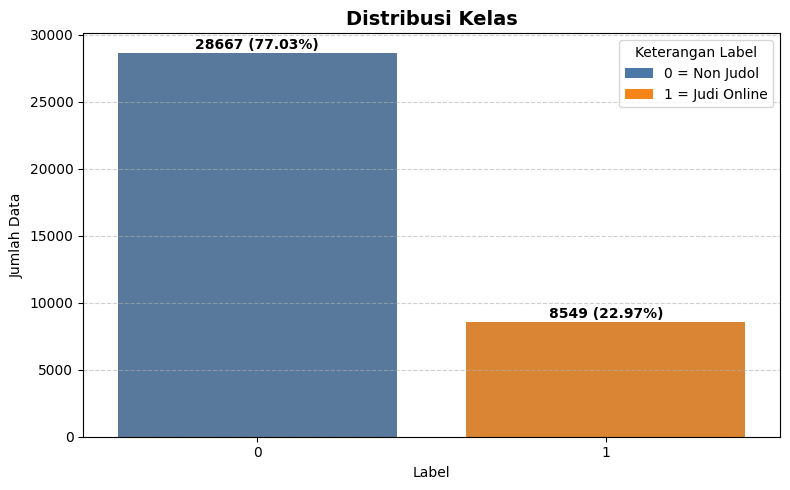

,label,jumlah,persentase
0,0,28667,77.03
1,1,8549,22.97


In [9]:
from matplotlib.patches import Patch
# Visualisasi distribusi kelas (label)
label_counts = y.value_counts().sort_index()
label_pct = (label_counts / label_counts.sum() * 100).round(2)

dist_df = pd.DataFrame({
    "label": label_counts.index.astype(str),
    "jumlah": label_counts.values,
    "persentase": label_pct.values
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=dist_df, x="label", y="jumlah", palette=["#4C78A8", "#F58518"])

for i, row in dist_df.iterrows():
    ax.text(
        i,
        row["jumlah"] + (dist_df["jumlah"].max() * 0.01),
        f'{int(row["jumlah"])} ({row["persentase"]}%)',
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Distribusi Kelas", fontsize=14, fontweight="bold")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Legend keterangan label
legend_elements = [
    Patch(facecolor="#4C78A8", label="0 = Non Judol"),
    Patch(facecolor="#F58518", label="1 = Judi Online")
]
plt.legend(handles=legend_elements, title="Keterangan Label")

plt.tight_layout()
plt.show()

dist_df

## Preprocessing

In [ ]:
import re
import unicodedata
import json

with open(
    "dataset/obfuscation_mapping.json",
    "r",
    encoding="utf-8"
) as f:
    OBF_MAP = json.load(f)

def replace_obfuscation(text, mapping):

    return ''.join(
        mapping.get(char, char)
        for char in text
    )


def preprocess_text(text):

    # 1. Handle Missing Value
    if text is None:
        return ""

    text = str(text)

    # 2. Unicode Normalization
    text = unicodedata.normalize('NFKC', text)

    # 3. Replace Obfuscation Characters
    text = replace_obfuscation(text, OBF_MAP)

    # 4. Unicode Normalization Again
    text = unicodedata.normalize('NFKD', text)

    # hapus combining marks hasil NFKD
    text = ''.join(
        c for c in text
        if not unicodedata.combining(c)
    )

    # 5. Case Folding
    text = text.lower()

    # 6. URL Normalization
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' URL ',
        text
    )

    # 7. Email Normalization
    text = re.sub(
        r'\S+@\S+',
        ' EMAIL ',
        text
    )

    # 9. Cleaning
    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    # 10. Multiple Spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

In [11]:
# Apply ke train dan test:
X_train = X_train.apply(preprocess_text)
X_test = X_test.apply(preprocess_text)

In [12]:
X_train.head()

0                           dubbing nya bahasa inggris
1    semoga rezeki dari macantoto membawa keberuntu...
2                                        terlalu panik
3                           rusak kabehhh pare batur a
4    itu keong pasti anyir banget lebih anyir dari ...
Name: comment_text, dtype: object

In [13]:
X_test.head()

0    seengaknya praz dah laku dan punya buntut jadi...
1    wow mona d bener bener beda ceritanya mengalir...
2       seriusan sampe mimpi pun gue kebayang pulauwin
3                                         anak lengser
4                       alah nyeri kulit beuteung mang
Name: comment_text, dtype: object

## TF-IDF

In [14]:
def tfidf_transform(X_train, X_test, max_features=5000, ngram_range=(1,1)):
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
    return X_train_tfidf, X_test_tfidf

X_train_tfidf, X_test_tfidf = tfidf_transform(X_train, X_test)

## Evaluasi Model

In [15]:
def evaluate_model(model, X_test, y_test, title="Model"):

    y_pred = model.predict(X_test)

    print(f"=== {title} ===")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='viridis',
        cbar=True
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

## Learning Curve

In [16]:
def plot_learning_curve(model, X, y, title="Learning Curve"):

    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure(figsize=(8,5))

    plt.plot(
        train_sizes,
        train_mean,
        marker='o',
        label='Training Score'
    )

    plt.plot(
        train_sizes,
        test_mean,
        marker='o',
        label='Validation Score'
    )

    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.title(title)

    plt.grid(
        True,
        linestyle='--',
        alpha=0.7
    )

    plt.legend()

    plt.show()

## SKENARIO 1 - BASELINE
Eksperimen baseline dilakukan untuk mengevaluasi performa awal algoritma klasifikasi (Logistic Regression, Random Forest, dan Support Vector Machine) pada dataset asli tanpa penerapan teknik penanganan ketidakseimbangan data. Hasil dari eksperimen ini digunakan sebagai acuan untuk membandingkan efektivitas eksperimen lainnya.

=== Baseline - Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5734
           1       0.95      0.96      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.97      0.97      0.97      7444
weighted avg       0.98      0.98      0.98      7444



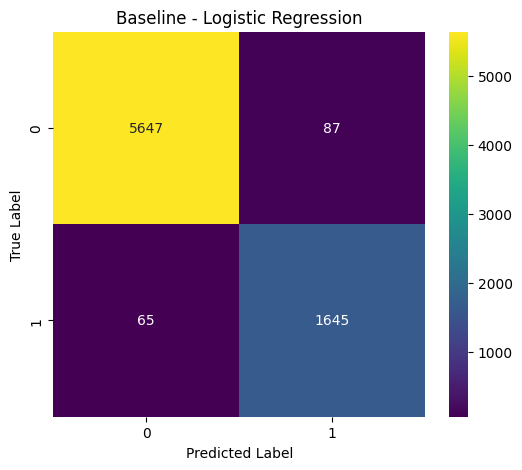

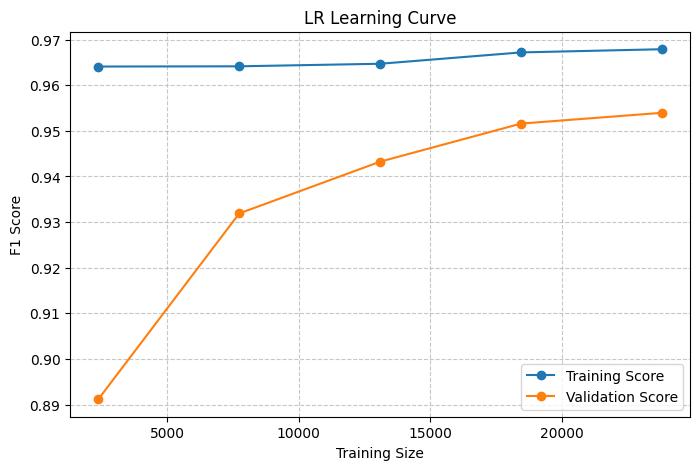

In [17]:
model_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42)
model_lr.fit(X_train_tfidf, y_train)

evaluate_model(model_lr, X_test_tfidf, y_test, "Baseline - Logistic Regression")
plot_learning_curve(model_lr, X_train_tfidf, y_train, "LR Learning Curve")

=== Baseline - Random Forest ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5734
           1       0.98      0.95      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.98      0.97      0.98      7444
weighted avg       0.98      0.98      0.98      7444



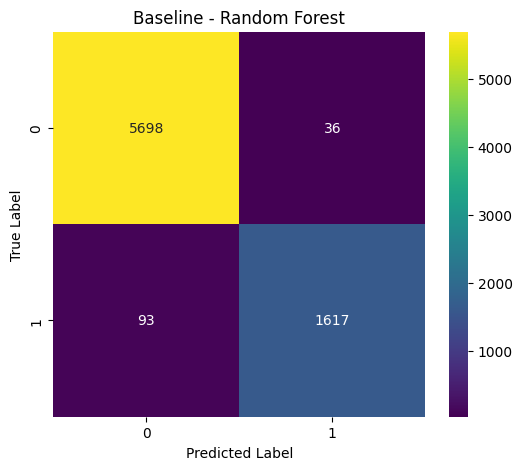

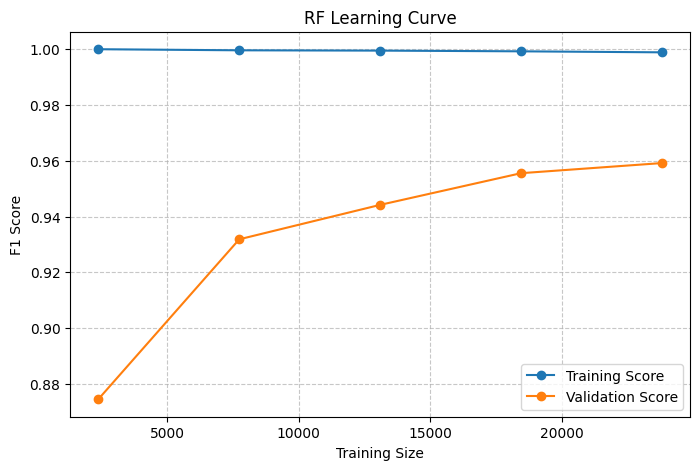

In [18]:
# Model Random Forest (baseline)
model_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42)

# Training
model_rf.fit(X_train_tfidf, y_train)

# Evaluasi
evaluate_model(model_rf, X_test_tfidf, y_test, "Baseline - Random Forest")

# Learning Curve
plot_learning_curve(model_rf, X_train_tfidf, y_train, "RF Learning Curve")

=== Baseline - SVM ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5734
           1       0.96      0.97      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.97      0.98      0.98      7444
weighted avg       0.98      0.98      0.98      7444



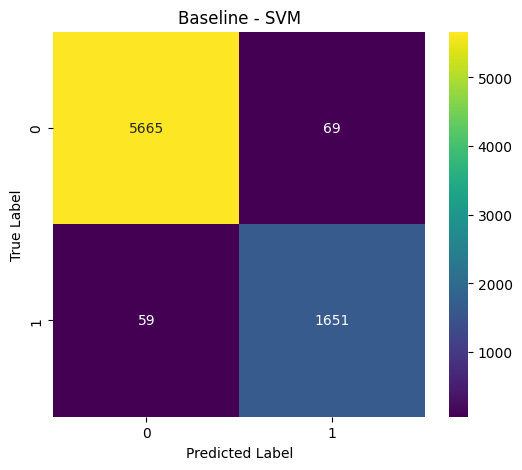

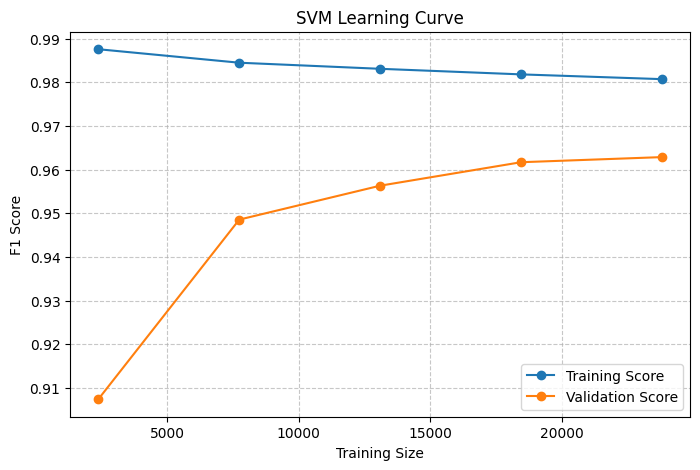

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Model SVM (baseline)
model_svm = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
    )

# Training
model_svm.fit(X_train_tfidf, y_train)

# Evaluasi
evaluate_model(model_svm, X_test_tfidf, y_test, "Baseline - SVM")

# Learning Curve (opsional, tanpa SMOTE)
plot_learning_curve(model_svm, X_train_tfidf, y_train, "SVM Learning Curve")

In [20]:
# Cross Validation Baseline SVM
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_svm_cv = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_svm_cv,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation Baseline SVM =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== Cross Validation Baseline SVM =====
F1-score tiap fold : [0.9658926  0.96312523 0.96255507 0.96075581 0.96301668]
Mean F1-score      : 0.9630690769878084
Std Dev            : 0.0016488518634514622


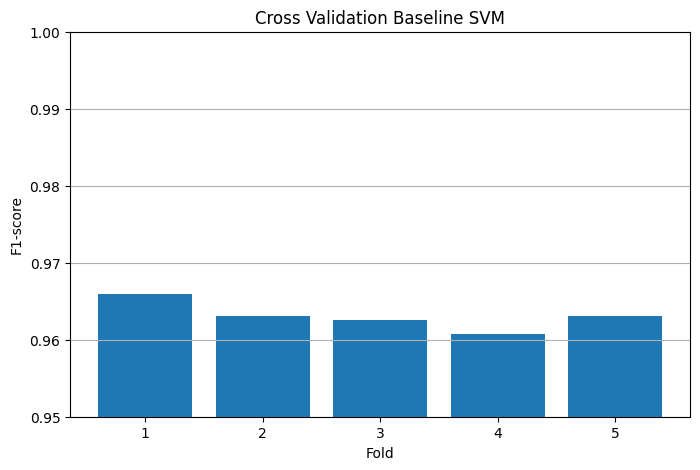

In [21]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Cross Validation Baseline SVM")
plt.ylim(0.95,1.0)
plt.grid(axis='y')

plt.show()

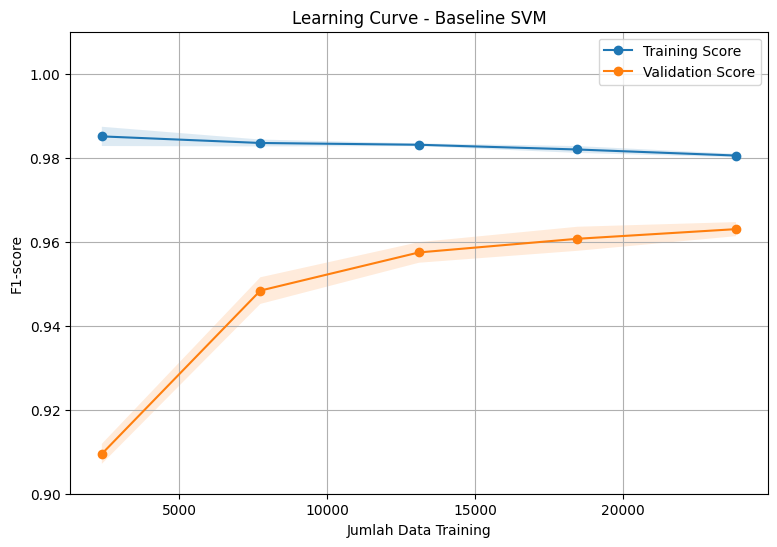

In [22]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_svm_lc = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_svm_lc,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("Learning Curve - Baseline SVM")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.90,1.01)

plt.show()

## SKENARIO 2 - SMOTE
Eksperimen oversampling menggunakan SMOTE bertujuan untuk mengatasi ketidakseimbangan distribusi kelas dengan menambahkan sampel sintetis pada kelas minoritas. Eksperimen ini dilakukan untuk mengetahui apakah penambahan data pada kelas minoritas dapat meningkatkan kemampuan model dalam mendeteksi komentar promosi judi online.

=== SMOTE + Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5734
           1       0.94      0.97      0.95      1710

    accuracy                           0.98      7444
   macro avg       0.96      0.97      0.97      7444
weighted avg       0.98      0.98      0.98      7444



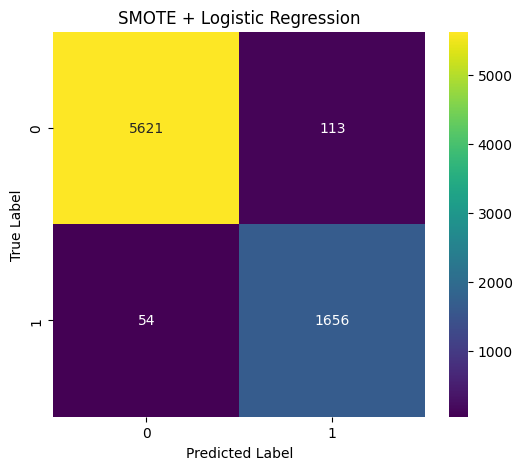

c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\OneDrive\Documents\Kul

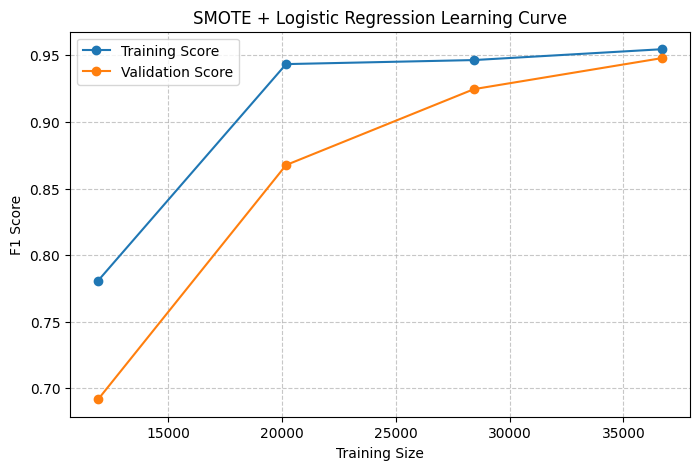

In [23]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

model_lr_smote = LogisticRegression(max_iter=1000, random_state=42)
model_lr_smote.fit(X_train_smote, y_train_smote)

evaluate_model(model_lr_smote, X_test_tfidf, y_test, "SMOTE + Logistic Regression")
plot_learning_curve(model_lr_smote, X_train_smote, y_train_smote, "SMOTE + Logistic Regression Learning Curve")

=== SMOTE + Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5734
           1       0.96      0.95      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.97      0.97      0.97      7444
weighted avg       0.98      0.98      0.98      7444



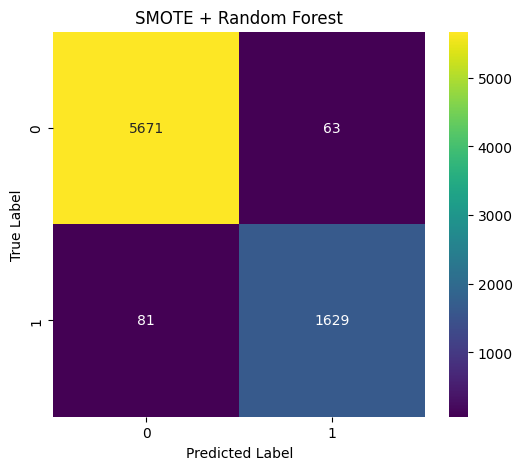

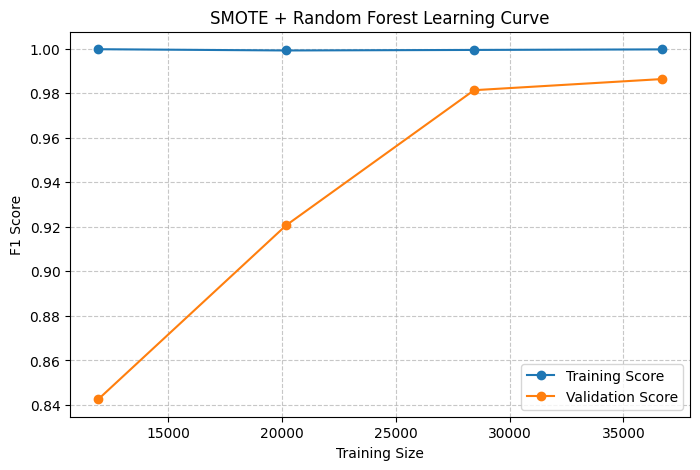

In [24]:
model_rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42)
model_rf_smote.fit(X_train_smote, y_train_smote)

evaluate_model(model_rf_smote, X_test_tfidf, y_test, "SMOTE + Random Forest")
plot_learning_curve(model_rf_smote, X_train_smote, y_train_smote, "SMOTE + Random Forest Learning Curve")

=== SMOTE + SVM ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5734
           1       0.95      0.97      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.97      0.98      0.97      7444
weighted avg       0.98      0.98      0.98      7444



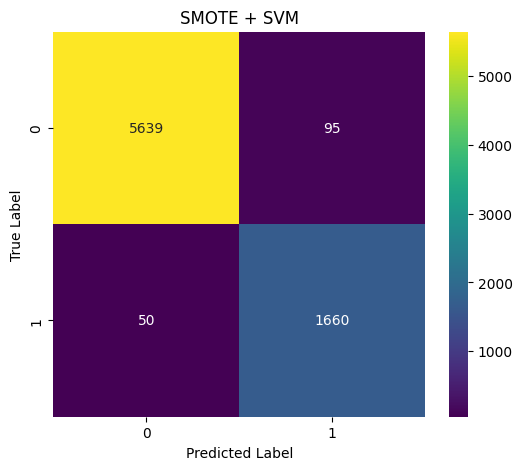

c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\OneDrive\Documents\Kul

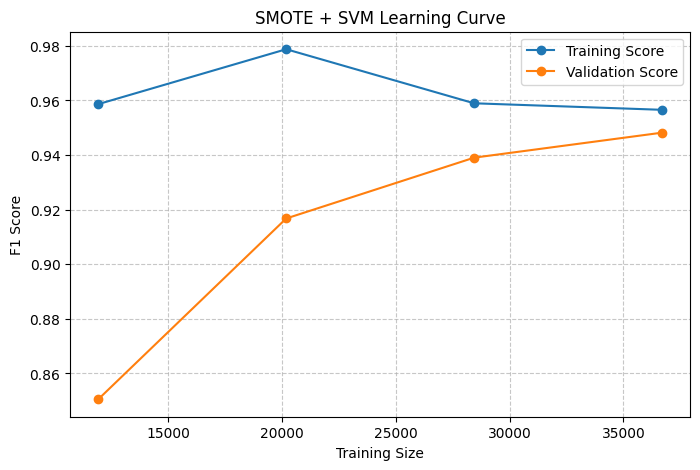

In [25]:
model_svm_smote = SVC(
    kernel='linear',
    probability=True,
    random_state=42
    )
model_svm_smote.fit(X_train_smote, y_train_smote)

evaluate_model(model_svm_smote, X_test_tfidf, y_test, "SMOTE + SVM")
plot_learning_curve(model_svm_smote, X_train_smote, y_train_smote, "SMOTE + SVM Learning Curve")

## SKENARIO 3 - UNDERSAMPLING
Eksperimen undersampling bertujuan untuk mengatasi ketidakseimbangan data dengan mengurangi jumlah sampel pada kelas mayoritas sehingga distribusi kelas menjadi lebih seimbang. Eksperimen ini dilakukan untuk mengevaluasi pengaruh pengurangan data mayoritas terhadap performa model klasifikasi.

In [26]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_tfidf, y_train)

=== UnderSampling + Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      5734
           1       0.94      0.96      0.95      1710

    accuracy                           0.98      7444
   macro avg       0.96      0.97      0.97      7444
weighted avg       0.98      0.98      0.98      7444



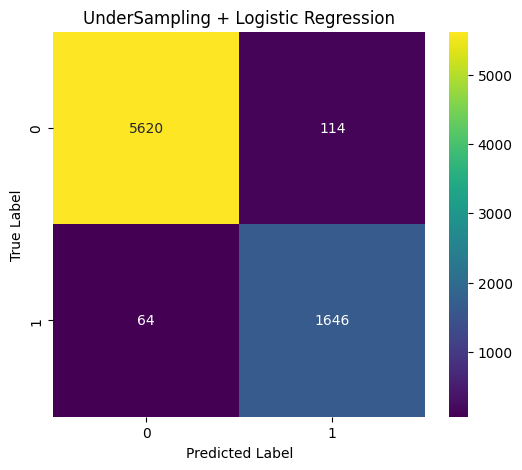

c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\OneDrive\Documents\K

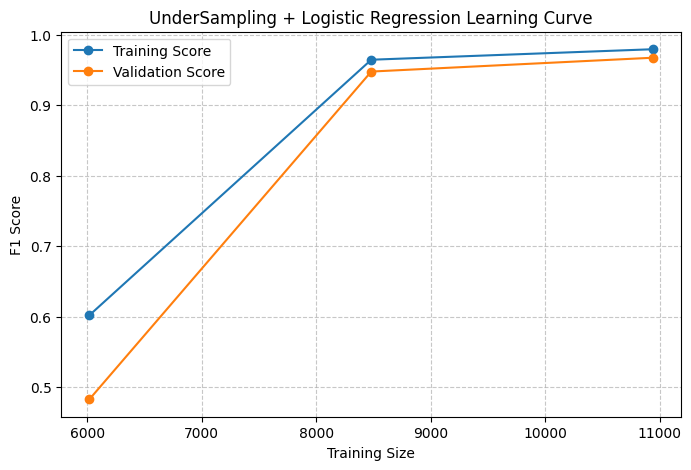

In [27]:
model_lr_under = LogisticRegression(max_iter=1000, random_state=42)
model_lr_under.fit(X_train_under, y_train_under)

evaluate_model(model_lr_under, X_test_tfidf, y_test, "UnderSampling + Logistic Regression")
plot_learning_curve(model_lr_under, X_train_under, y_train_under, "UnderSampling + Logistic Regression Learning Curve")

=== Undersampling + RF ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5734
           1       0.90      0.98      0.94      1710

    accuracy                           0.97      7444
   macro avg       0.95      0.97      0.96      7444
weighted avg       0.97      0.97      0.97      7444



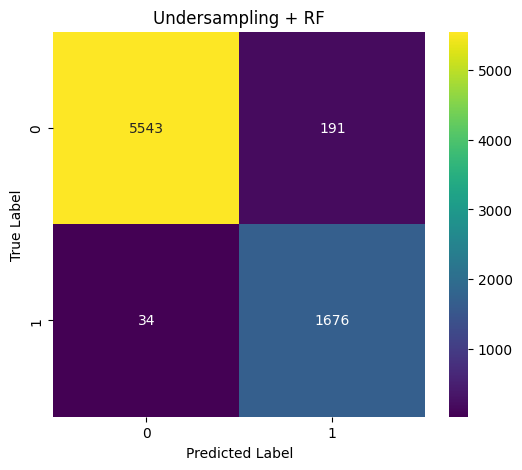

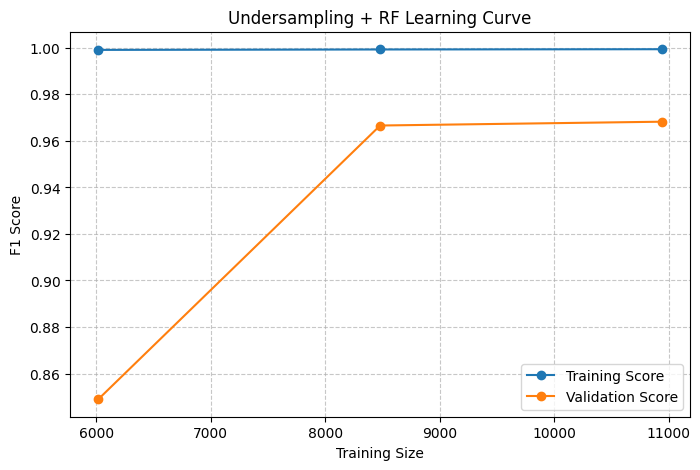

In [28]:
model_rf_under = RandomForestClassifier(n_estimators=300, random_state=42)
model_rf_under.fit(X_train_under, y_train_under)

evaluate_model(model_rf_under, X_test_tfidf, y_test, "Undersampling + RF")
plot_learning_curve(model_rf_under, X_train_under, y_train_under, "Undersampling + RF Learning Curve")

=== Undersampling + SVM ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5734
           1       0.95      0.97      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.97      0.98      0.97      7444
weighted avg       0.98      0.98      0.98      7444



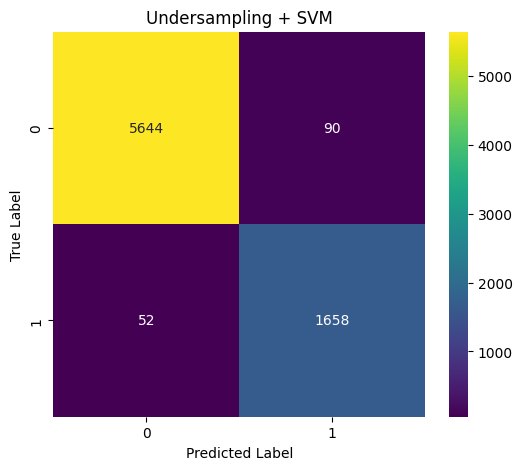

c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\OneDrive\Documents\K

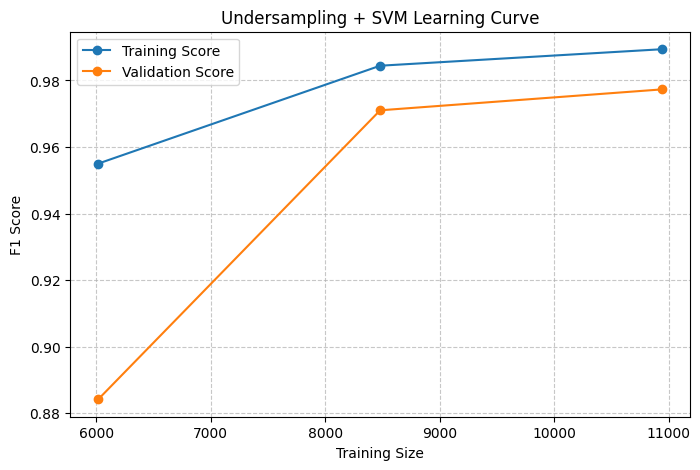

In [29]:
model_svm_under = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)
model_svm_under.fit(X_train_under, y_train_under)

evaluate_model(model_svm_under, X_test_tfidf, y_test, "Undersampling + SVM")
plot_learning_curve(model_svm_under, X_train_under, y_train_under, "Undersampling + SVM Learning Curve")

## SKENARIO 4 - TF-IDF VARIATION (BIGRAM)
Eksperimen variasi TF-IDF dengan bigram bertujuan untuk mengevaluasi pengaruh penggunaan kombinasi dua kata berurutan (n-gram = 2) terhadap performa model klasifikasi. Pendekatan ini diharapkan mampu menangkap konteks frasa yang lebih spesifik dibandingkan representasi unigram, sehingga dapat meningkatkan kemampuan model dalam mengenali pola komentar promosi judi online.

In [30]:
X_train_bigram, X_test_bigram = tfidf_transform(
    X_train, X_test, max_features=5000, ngram_range=(1,2)
)

=== Bigram - LR ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      5734
           1       0.98      0.91      0.95      1710

    accuracy                           0.98      7444
   macro avg       0.98      0.95      0.97      7444
weighted avg       0.98      0.98      0.98      7444



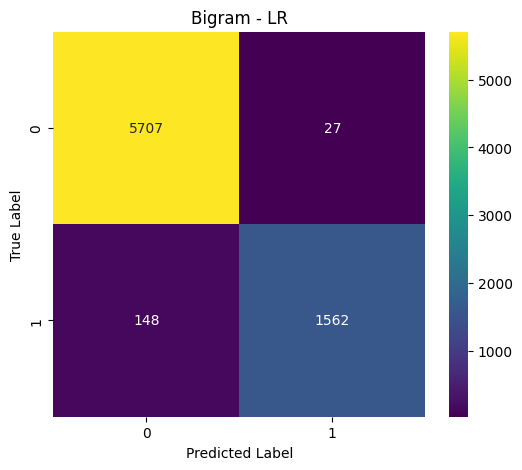

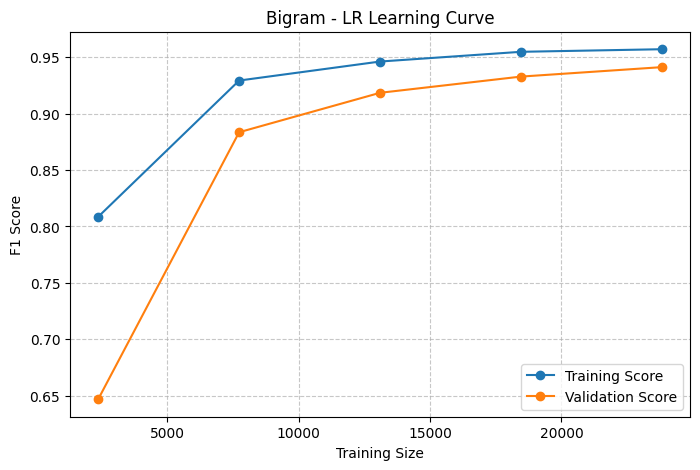

In [31]:
# Model Logistic Regression dengan Bigram
model_lr_bigram = LogisticRegression(max_iter=1000)
model_lr_bigram.fit(X_train_bigram, y_train)

evaluate_model(model_lr_bigram, X_test_bigram, y_test, "Bigram - LR")
plot_learning_curve(model_lr_bigram, X_train_bigram, y_train, "Bigram - LR Learning Curve")

=== Bigram - RF ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5734
           1       0.98      0.95      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.98      0.97      0.98      7444
weighted avg       0.98      0.98      0.98      7444



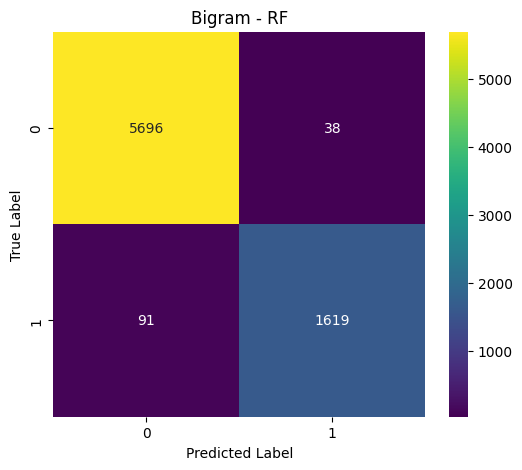

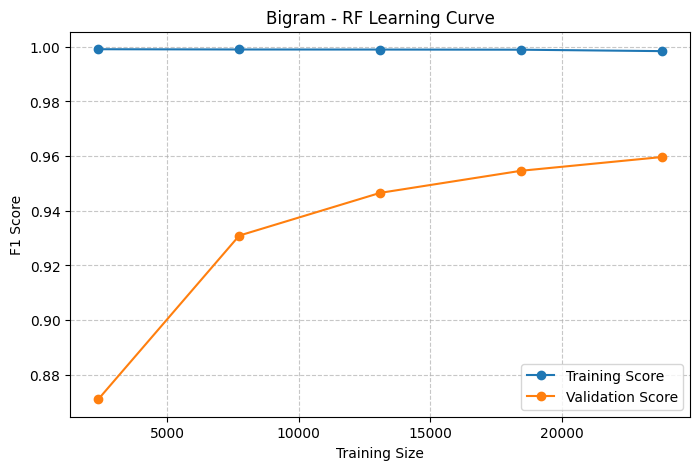

In [32]:
# Model Random Forest dengan Bigram
model_rf_bigram = RandomForestClassifier(n_estimators=300, random_state=42)
model_rf_bigram.fit(X_train_bigram, y_train)

evaluate_model(model_rf_bigram, X_test_bigram, y_test, "Bigram - RF")
plot_learning_curve(model_rf_bigram, X_train_bigram, y_train, "Bigram - RF Learning Curve")

=== Bigram - SVM ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      5734
           1       0.98      0.94      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.98      0.97      0.98      7444
weighted avg       0.98      0.98      0.98      7444



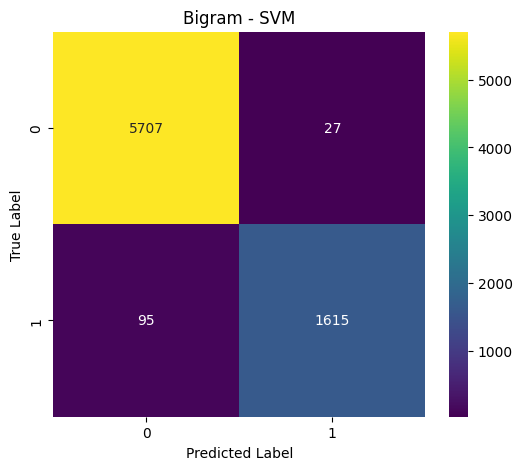

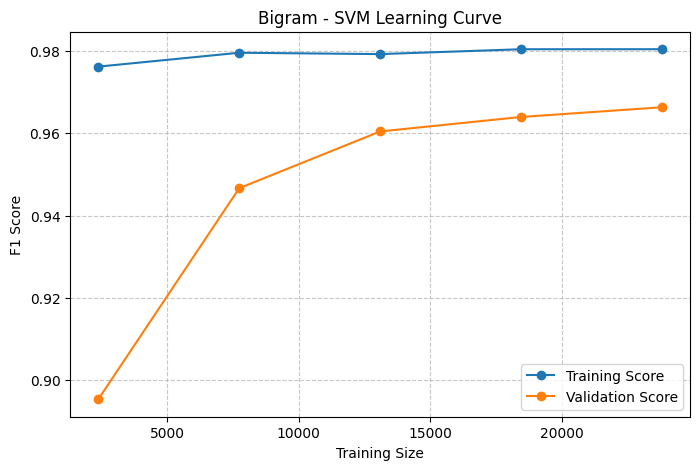

In [33]:
# Model Support Vector Machine dengan Bigram
model_svm_bigram = SVC(kernel='linear', probability=True, random_state=42)
model_svm_bigram.fit(X_train_bigram, y_train)

evaluate_model(model_svm_bigram, X_test_bigram, y_test, "Bigram - SVM")
plot_learning_curve(model_svm_bigram, X_train_bigram, y_train, "Bigram - SVM Learning Curve")

## SKENARIO 5 - HYPERPARAMETER TUNING

**Logistic Regression**

Best LR: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}
Best CV F1 Score: 0.9647879473014562
=== Tuned LR ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5734
           1       0.96      0.97      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.98      0.98      0.98      7444
weighted avg       0.98      0.98      0.98      7444



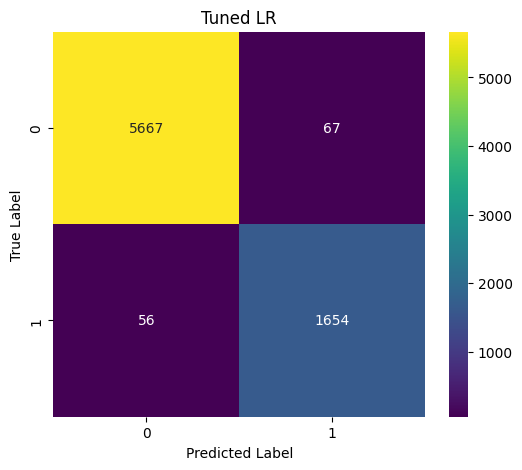

In [34]:
param_lr = param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'saga'],
        'class_weight': ['balanced']
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'class_weight': ['balanced']
    }
]

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000), 
    param_lr, 
    cv=5, 
    scoring='f1',
    n_jobs=-1)
grid_lr.fit(X_train_tfidf, y_train)

print("Best LR:", grid_lr.best_params_)
print("Best CV F1 Score:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
evaluate_model(best_lr, X_test_tfidf, y_test, "Tuned LR")

**RF**

Best RF: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.9677472909865706
=== Tuned RF ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5734
           1       0.99      0.96      0.97      1710

    accuracy                           0.99      7444
   macro avg       0.99      0.98      0.98      7444
weighted avg       0.99      0.99      0.99      7444



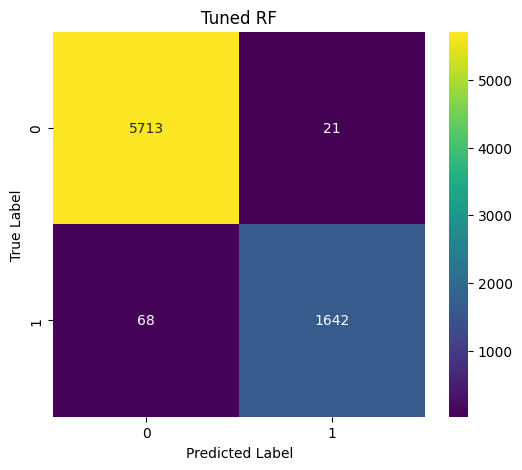

In [35]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_rf, 
    cv=5, 
    scoring='f1',
    n_jobs=-1)
grid_rf.fit(X_train_tfidf, y_train)

print("Best RF:", grid_rf.best_params_)
print("Best CV F1 Score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
evaluate_model(best_rf, X_test_tfidf, y_test, "Tuned RF")

**SVM**

Best SVM: {'C': 1, 'class_weight': 'balanced', 'kernel': 'linear'}
Best CV F1 Score: 0.9628494613026201
=== Tuned SVM ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5734
           1       0.96      0.97      0.96      1710

    accuracy                           0.98      7444
   macro avg       0.97      0.98      0.98      7444
weighted avg       0.98      0.98      0.98      7444



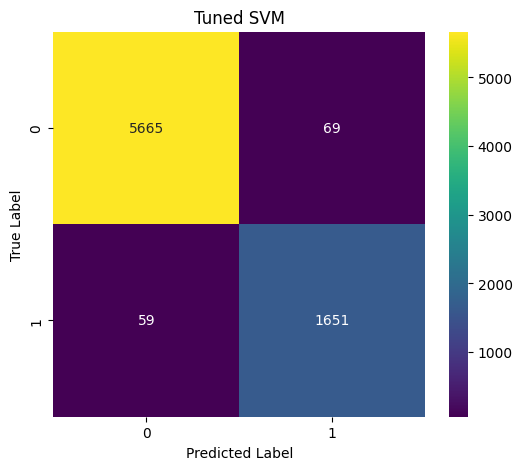

In [36]:
param_svm = {
    'C': [0.01, 0.1, 1, 10],
    'kernel': ['linear'],
    'class_weight': ['balanced']
}

grid_svm = GridSearchCV(
    SVC(probability=True), 
    param_svm, 
    cv=5, 
    scoring='f1',
    n_jobs=-1)
grid_svm.fit(X_train_tfidf, y_train)

print("Best SVM:", grid_svm.best_params_)
print("Best CV F1 Score:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_
evaluate_model(best_svm, X_test_tfidf, y_test, "Tuned SVM")

## Perbandingan Hasil Evaluasi Model

In [37]:
from numpy import add


results = []

def add_result(name, model, X_test, y_test):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

# Tambahkan hasil
add_result("Baseline LR", model_lr, X_test_tfidf, y_test)
add_result("Baseline SVM", model_svm, X_test_tfidf, y_test)
add_result("Baseline RF", model_rf, X_test_tfidf, y_test)
add_result("SMOTE + LR", model_lr_smote, X_test_tfidf, y_test)
add_result("SMOTE + SVM", model_svm_smote, X_test_tfidf, y_test)
add_result("SMOTE + RF", model_rf_smote, X_test_tfidf, y_test)
add_result("Undersampling + LR", model_lr_under, X_test_tfidf, y_test)
add_result("Undersampling + RF", model_rf_under, X_test_tfidf, y_test)
add_result("Undersampling + SVM", model_svm_under, X_test_tfidf, y_test)
add_result("Tuned LR", best_lr, X_test_tfidf, y_test)
add_result("Tuned RF", best_rf, X_test_tfidf, y_test)
add_result("Tuned SVM", best_svm, X_test_tfidf, y_test)

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,Precision,Recall,F1
0,Baseline LR,0.979581,0.949769,0.961988,0.955840
1,Baseline SVM,0.982805,0.959884,0.965497,0.962682
2,Baseline RF,0.982671,0.978221,0.945614,0.961641
3,SMOTE + LR,0.977566,0.936122,0.968421,0.951998
4,SMOTE + SVM,0.980521,0.945869,0.970760,0.958153
5,SMOTE + RF,0.980656,0.962766,0.952632,0.957672
6,Undersampling + LR,0.976088,0.935227,0.962573,0.948703
7,Undersampling + RF,0.969774,0.897697,0.980117,0.937098
8,Undersampling + SVM,0.980924,0.948513,0.969591,0.958936
9,Tuned LR,0.983477,0.961069,0.967251,0.964150


## Visualisasi Perbandingan

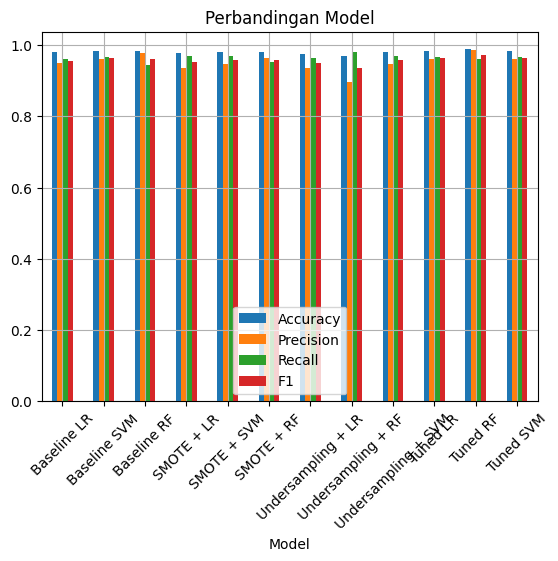

In [38]:
df_results.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(kind="bar")
plt.title("Perbandingan Model")
plt.xticks(rotation=45)
plt.grid()
plt.show()